# ECG Classification - Transformer with Attention (v5)

This notebook implements a Transformers use self-attention mechanisms to capture long-range dependencies in the ECG signal, which is important for detecting abnormal patterns that may span across the entire heartbeat.

**Input**: 188 columns of ECG time series data
**Output**: Binary classification (0 = normal, 1 = abnormal)

**Architecture**: 
- Custom PositionalEncoding layer (learnable embeddings)
- 3 Transformer encoder blocks with Multi-Head Attention (4 heads)
- GlobalAveragePooling1D
- MLP head: Dense(128) → Dense(64) → Output

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Conv1D, Add, Embedding
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

2025-11-27 06:55:00.157758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764226500.359065      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764226500.410990      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Data Loading

In [2]:
# Load data
try:
    df1 = pd.read_csv('/kaggle/input/ecg-dataset/ecg.csv', header=None)
    df2 = pd.read_csv('/kaggle/input/ecg2-dataset/ecg3.csv', header=None)
    df2 = df2.rename(columns={0: 'orig_0'})
    df2.insert(0, 0, df2['orig_0'])
    df2.columns = range(df2.shape[1])
    df = pd.concat([df1, df2], ignore_index=True)
except:
    df = pd.read_csv('../../dataset_aritmia_NEW.csv')

print(f'Dataset shape: {df.shape}')

Dataset shape: (5025, 189)


In [3]:
# Add column names
n_features = df.shape[1] - 1
column_names = [f'f{i}' for i in range(n_features)] + ['label']
df.columns = column_names
print(f'Number of features (timesteps): {n_features}')
df.head()

Number of features (timesteps): 188


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f179,f180,f181,f182,f183,f184,f185,f186,f187,label
0,955,954,954,956,958,955,955,953,954,956,...,941,940,940,939,941,941,942,937,938,0
1,952,953,953,953,949,947,953,952,953,952,...,946,949,951,947,948,946,949,949,951,0
2,955,948,952,952,955,955,954,953,955,958,...,939,934,935,934,937,935,930,933,932,0
3,957,958,958,958,956,956,956,959,959,959,...,939,939,942,942,940,938,935,936,937,0
4,958,958,960,960,958,958,959,961,961,961,...,944,946,949,949,950,947,946,946,946,0


In [4]:
# Check label distribution
print('Label distribution:')
print(df['label'].value_counts())
print('\nPercentage:')
print(df['label'].value_counts(normalize=True) * 100)

Label distribution:
label
0    2736
1    2289
Name: count, dtype: int64

Percentage:
label
0    54.447761
1    45.552239
Name: proportion, dtype: float64


## Data Preprocessing

In [5]:
# Prepare features and labels
X = df.drop('label', axis=1).values
y = df['label'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for Transformer: (samples, timesteps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y_categorical.shape}')
print(f'Classes: {le.classes_}')

X shape: (5025, 188, 1)
y shape: (5025, 2)
Classes: [0 1]


In [6]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Compute class weights
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_classes), y=y_train_classes)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')
print(f'\nTrain shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Class weights: {0: 0.918227501142074, 1: 1.0977607864554888}

Train shape: (4020, 188, 1)
Test shape: (1005, 188, 1)


## Transformer Model Architecture

In [7]:
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Single transformer encoder block.
    # Multi-head self-attention
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size, 
        num_heads=num_heads, 
        dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    res = Add()([x, inputs])
    
    # Feed-forward network
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return Add()([x, res])


class PositionalEncoding(tf.keras.layers.Layer):
    # Learnable positional encoding layer.
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        self.position_embedding = self.add_weight(
            name='position_embedding',
            shape=(sequence_length, d_model),
            initializer='glorot_uniform',
            trainable=True
        )
    
    def call(self, x):
        return x + self.position_embedding
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'sequence_length': self.sequence_length,
            'd_model': self.d_model
        })
        return config

In [8]:
def create_transformer_model(
    input_shape,
    num_classes,
    head_size=32,
    num_heads=4,
    ff_dim=64,
    num_transformer_blocks=2,
    mlp_units=[128, 64],
    dropout=0.2,
    mlp_dropout=0.3
):
    # Create Transformer model for ECG classification.
    d_model = 64
    
    inputs = Input(shape=input_shape)
    
    # Project input to higher dimension for attention
    x = Dense(d_model)(inputs)
    
    # Add positional encoding using custom layer
    x = PositionalEncoding(sequence_length=input_shape[0], d_model=d_model)(x)
    
    # Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout)
    
    # Global pooling
    x = GlobalAveragePooling1D()(x)
    
    # MLP head
    for units in mlp_units:
        x = Dense(units, activation='relu')(x)
        x = Dropout(mlp_dropout)(x)
    
    # Output
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

In [9]:
# Create model
model = create_transformer_model(
    input_shape=(X_train.shape[1], 1),
    num_classes=y_categorical.shape[1],
    head_size=32,
    num_heads=4,
    ff_dim=64,
    num_transformer_blocks=3,
    mlp_units=[128, 64],
    dropout=0.2,
    mlp_dropout=0.3
)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1764226514.388178      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 188, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 188, 64)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 188, 64)   │     12,032 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 188, 64)   │        128 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 188, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 188, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 188, 64)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 188, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 188, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 188, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 188, 64)   │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 188, 64)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 188, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 188, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 188, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 188, 64)   │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 188, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 188, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 188, 64)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 154,242 (602.51 KB)

 Trainable params: 154,242 (602.51 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Callbacks
callbacks = [
    ModelCheckpoint(
        'ecg_transformer_model.h5',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [11]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/150


I0000 00:00:1764226524.088779     111 service.cc:148] XLA service 0x793a2c00bad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764226524.089220     111 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764226525.319084     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


 18/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7971 - loss: 0.4732

I0000 00:00:1764226532.841892     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9058 - loss: 0.2565
Epoch 1: val_loss improved from inf to 0.02983, saving model to ecg_transformer_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.9062 - loss: 0.2556 - val_accuracy: 0.9960 - val_loss: 0.0298 - learning_rate: 5.0000e-04
Epoch 2/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9930 - loss: 0.0525
Epoch 2: val_loss improved from 0.02983 to 0.02493, saving model to ecg_transformer_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9930 - loss: 0.0525 - val_accuracy: 0.9960 - val_loss: 0.0249 - learning_rate: 5.0000e-04
Epoch 3/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9928 - loss: 0.0499
Epoch 3: val_loss improved from 0.02493 to 0.02379, saving model to ecg_transformer_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9928 - loss: 0.0499 - val_accuracy: 0.9960 - val_loss: 0.0238 - learning_rate: 5.0000e-04
Epoch 4/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9944 - loss: 0.0404
Epoch 4: val_loss did not improve from 0.02379
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9943 - loss: 0.0408 - val_accuracy: 0.9960 - val_loss: 0.0239 - learning_rate: 5.0000e-04
Epoch 5/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9936 - loss: 0.0414
Epoch 5: val_loss did not improve from 0.02379
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9935 - loss: 0.0418 - val_accuracy: 0.9960 - val_loss: 0.0268 - learning_rate: 5.0000e-04
Epoch 6/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9890 - loss: 0.0654
Epoch 6: val_loss did not improve from 0.02379
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9890 - loss: 0.0653 - val_accuracy: 0.9960 - val_loss: 0.0278 - learning_rate: 5.0000e-04
Epoch 7/150

126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9930 - loss: 0.0478 - val_accuracy: 0.9960 - val_loss: 0.0233 - learning_rate: 5.0000e-04
Epoch 8/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9925 - loss: 0.0501
Epoch 8: val_loss did not improve from 0.02328
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9925 - loss: 0.0501 - val_accuracy: 0.9960 - val_loss: 0.0259 - learning_rate: 5.0000e-04
Epoch 9/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9932 - loss: 0.0419
Epoch 9: val_loss did not improve from 0.02328
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9932 - loss: 0.0419 - val_accuracy: 0.9960 - val_loss: 0.0292 - learning_rate: 5.0000e-04
Epoch 10/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9931 - loss: 0.0438
Epoch 10: val_loss did not improve from 0.02328
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9931 - loss: 0.0439 - val_accuracy: 0.9940 - val_loss: 0.0416 - learning_rate: 5.0000e-04
Epoch 11/

126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9895 - loss: 0.0505 - val_accuracy: 0.9950 - val_loss: 0.0231 - learning_rate: 5.0000e-04
Epoch 16/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9948 - loss: 0.0309
Epoch 16: val_loss did not improve from 0.02305
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9948 - loss: 0.0309 - val_accuracy: 0.9950 - val_loss: 0.0329 - learning_rate: 5.0000e-04
Epoch 17/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9901 - loss: 0.0464
Epoch 17: val_loss did not improve from 0.02305
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9901 - loss: 0.0465 - val_accuracy: 0.9950 - val_loss: 0.0245 - learning_rate: 5.0000e-04
Epoch 18/150
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9927 - loss: 0.0422
Epoch 18: val_loss did not improve from 0.02305
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0420 - val_accuracy: 0.9950 - val_loss: 0.0243 - learning_rate: 5.0000e-04
Epoch

## Training Visualization

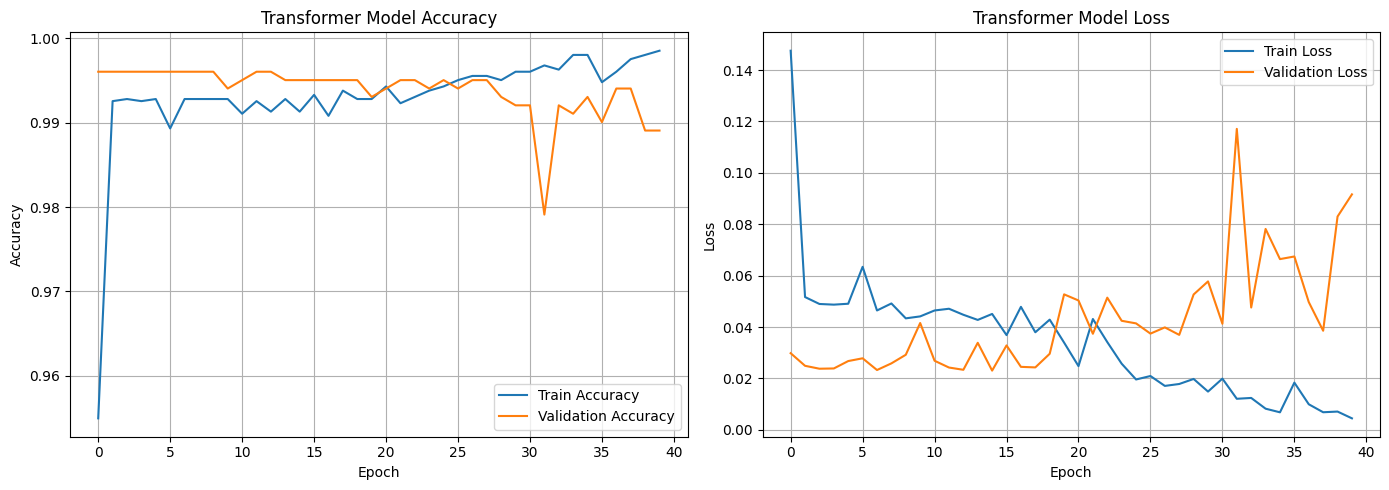

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Transformer Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Transformer Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

In [13]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9958 - loss: 0.0196

Test Loss: 0.0231
Test Accuracy: 0.9950


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


<Figure size 800x600 with 0 Axes>

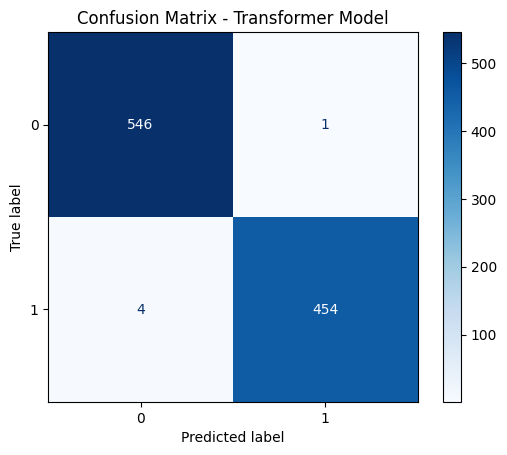

In [14]:
# Predictions and Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Transformer Model')
plt.show()

In [15]:
# Classification Report
target_names = [str(label) for label in le.classes_]
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       547
           1       1.00      0.99      0.99       458

    accuracy                           1.00      1005
   macro avg       1.00      0.99      0.99      1005
weighted avg       1.00      1.00      1.00      1005



In [16]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f'ROC-AUC Score: {roc_auc:.4f}')

ROC-AUC Score: 0.9978


## Attention Visualization

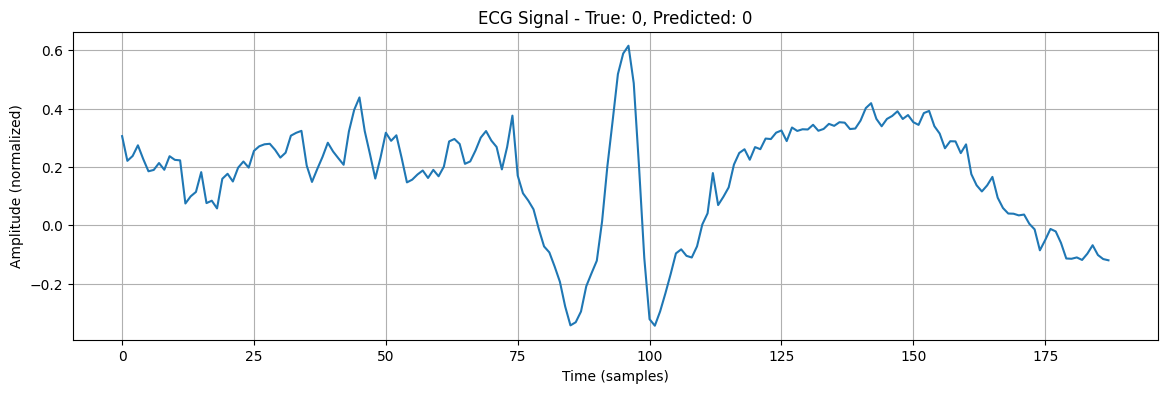

In [17]:
# Extract attention weights (simplified visualization)
# btw full attention visualization requires custom model modifications

# Visualize sample ECG with prediction
sample_idx = 0
sample_signal = X_test[sample_idx].flatten()
sample_pred = y_pred_classes[sample_idx]
sample_true = y_true_classes[sample_idx]

plt.figure(figsize=(14, 4))
plt.plot(sample_signal)
plt.title(f'ECG Signal - True: {le.classes_[sample_true]}, Predicted: {le.classes_[sample_pred]}')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (normalized)')
plt.grid(True)
plt.show()

## Prediction Function

In [18]:
def predict_ecg_transformer(signal, model, scaler, label_encoder):
    signal = np.array(signal).reshape(1, -1)
    signal_scaled = scaler.transform(signal)
    signal_scaled = signal_scaled.reshape(1, -1, 1)
    y_pred = model.predict(signal_scaled, verbose=0)
    predicted_class = np.argmax(y_pred)
    confidence = np.max(y_pred)
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]
    return predicted_label, confidence

In [19]:
# Test prediction with sample data (baseline ~958, peaks during beats)
sample_data = [
    952, 954, 956, 955, 955, 953, 952, 952, 951, 955, 953, 954, 952, 953, 952, 955,
    957, 958, 958, 962, 963, 964, 963, 965, 963, 967, 969, 971, 973, 973, 972, 971,
    973, 973, 972, 968, 966, 968, 970, 973, 969, 966, 960, 964, 965, 970, 971, 970,
    967, 964, 962, 961, 960, 954, 950, 951, 951, 951, 950, 950, 950, 948, 952, 949,
    949, 944, 940, 943, 944, 947, 948, 944, 941, 943, 945, 945, 945, 942, 938, 936,
    933, 926, 927, 920, 910, 909, 919, 940, 963, 986, 1020, 1068, 1121, 1167, 1193,
    1201, 1182, 1136, 1069, 1010, 967, 939, 924, 914, 917, 924, 931, 934, 934, 937,
    940, 942, 942, 941, 940, 939, 940, 938, 938, 936, 934, 934, 938, 938, 938, 935,
    935, 936, 939, 938, 938, 939, 935, 935, 938, 937, 937, 935, 935, 937, 938, 939,
    938, 938, 936, 940, 938, 939, 938, 936, 936, 938, 938, 941, 939, 938, 933, 935,
    935, 938, 938, 936, 936, 937, 938, 941, 941, 939, 939, 940, 943, 943, 941, 941,
    939, 938, 943, 943, 943, 943, 938, 941, 942, 941, 938, 935, 931, 932
]

predicted_label, confidence = predict_ecg_transformer(sample_data, model, scaler, le)
print(f'Prediction: {predicted_label}')
print(f'Confidence: {confidence:.4f}')
print(f'Expected: Normal (0)')

Prediction: 0
Confidence: 0.9959
Expected: Normal (0)


## Save Model

In [20]:
# Save the final model
model.save('ecg_transformer_final.h5')
print('model saved')

model saved
